# MacSentinel 05 · Temporal Graph ML

## tl;dr

Iterative message passing summarizes each process–file–network provenance graph, then a logistic detection head combines graph context with transparent session features. Evaluation is host-separated and includes model-driver inspection.

## Goal

Test whether temporal provenance features improve session-level threat detection and analyst explanations.

**Safety and scope:** all events are deterministic synthetic fixtures. Reserved `.example` domains and inert filenames are used; this project does not execute payloads, collect private data, or bypass platform controls.


## Setup

Load the shared synthetic macOS telemetry fixture and dependency-light visualization helpers. The data source and seed are explicit so every result can be reproduced offline.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from macsentinel.core import *
from macsentinel.visuals import *

SEED = 42
DATA_PATH = Path("macsentinel/data/synthetic_macos_events.csv")
events = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
FIGURES = []
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print(f"Loaded {len(events):,} synthetic events across {events.session_id.nunique():,} sessions and {events.host_id.nunique()} hosts.")


Loaded 2,520 synthetic events across 420 sessions and 30 hosts.


## Steps

### 1. Build graph and session features


In [2]:
graph_sessions = temporal_graph_features(events, rounds=3)
graph_columns = ["graph_node_count", "graph_edge_count", "graph_density", "process_influence", "file_influence", "domain_influence", "embedding_energy"]
model_columns = FEATURE_COLUMNS + graph_columns
train_index, test_index = group_train_test_split(graph_sessions, test_fraction=0.30)
features = graph_sessions[model_columns].fillna(0).to_numpy()
labels = graph_sessions.label.to_numpy()
print(graph_sessions[graph_columns].describe().round(3).to_string())


       graph_node_count  graph_edge_count  graph_density  process_influence  file_influence  domain_influence  embedding_energy
count           420.000           420.000        420.000            420.000         420.000           420.000           420.000
mean             10.826            11.840          0.198              0.836           0.321             0.254             0.745
std               1.269             0.386          0.040              0.012           0.067             0.134             0.008
min               8.000            10.000          0.142              0.793           0.000             0.000             0.716
25%              10.000            12.000          0.167              0.838           0.309             0.237             0.741
50%              11.000            12.000          0.190              0.841           0.320             0.309             0.746
75%              12.000            12.000          0.220              0.841           0.351             

### 2. Fit graph-augmented and flat baselines


In [3]:
graph_model = fit_logistic(features[train_index], labels[train_index], model_columns, steps=2200)
graph_scores = predict_logistic(graph_model, features[test_index])
graph_metrics = evaluate_scores(labels[test_index], graph_scores, 0.50)

flat_features = graph_sessions[FEATURE_COLUMNS].to_numpy()
flat_model = fit_logistic(flat_features[train_index], labels[train_index], FEATURE_COLUMNS)
flat_scores = predict_logistic(flat_model, flat_features[test_index])
flat_metrics = evaluate_scores(labels[test_index], flat_scores, 0.50)

comparison = pd.DataFrame([flat_metrics, graph_metrics], index=["flat telemetry", "temporal graph + telemetry"])
print(comparison[["precision", "recall", "f1", "average_precision", "alert_rate"]].round(3).to_string())


                            precision  recall     f1  average_precision  alert_rate
flat telemetry                  0.700   0.955  0.808              0.969       0.244
temporal graph + telemetry      0.846   1.000  0.917              0.996       0.211


## Visual Insights & ML Extension

### 3. Inspect the graph-feature space


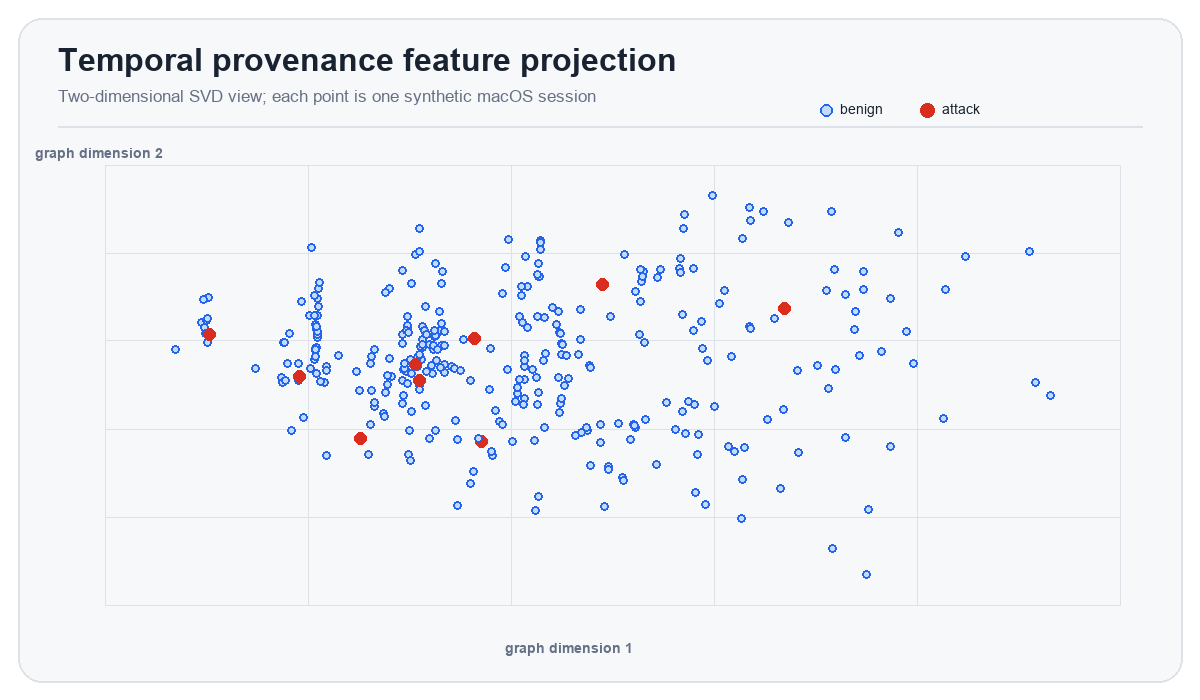

In [4]:
graph_values = graph_sessions[graph_columns].fillna(0).to_numpy()
standardized = (graph_values - graph_values.mean(axis=0)) / np.where(graph_values.std(axis=0) < 1e-6, 1, graph_values.std(axis=0))
_, _, components = np.linalg.svd(standardized, full_matrices=False)
projection = standardized @ components[:2].T
figure = scatter_chart(
    projection[:, 0], projection[:, 1], labels,
    "Temporal provenance feature projection",
    "Two-dimensional SVD view; each point is one synthetic macOS session",
    "graph dimension 1", "graph dimension 2",
)
FIGURES.append(figure)
figure


### 4. Explain the graph-augmented model


network_beacon_count          1.095
privilege_escalation_count    0.947
process_influence             0.813
rare_process_ratio            0.755
log1p_bytes_out               0.562
not_notarized_ratio           0.497
unsigned_ratio                0.497
domain_influence              0.441
embedding_energy              0.430
graph_edge_count              0.373


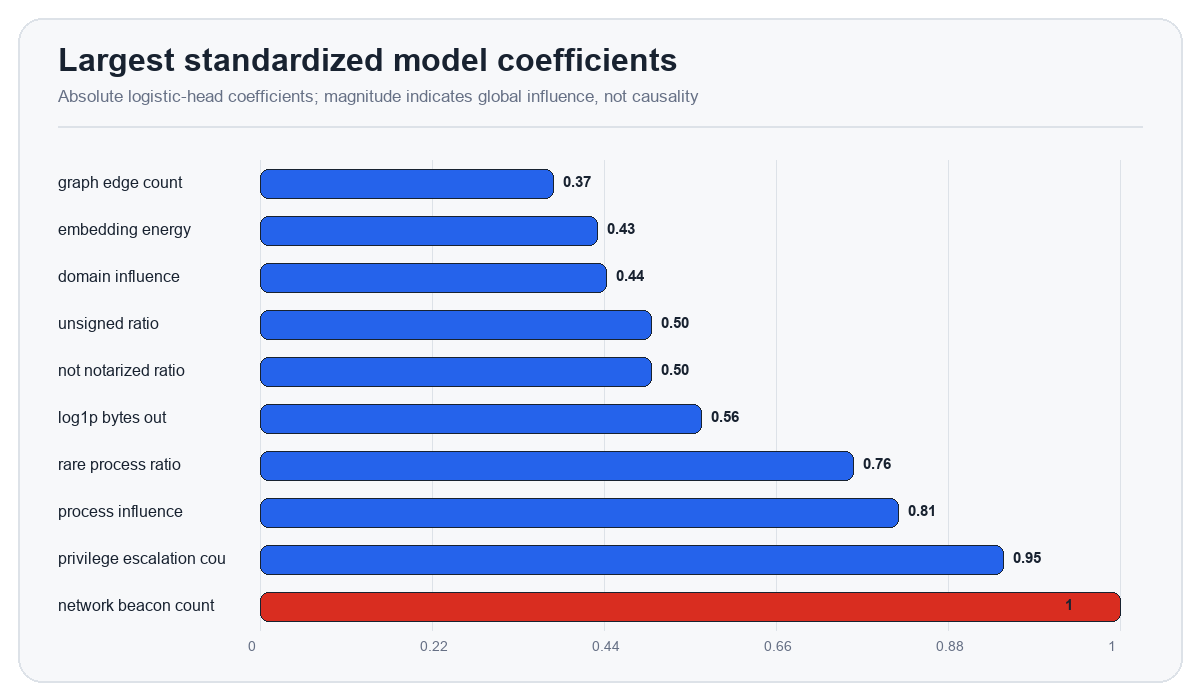

In [5]:
importance = pd.Series(np.abs(graph_model.weights[1:]), index=model_columns).sort_values(ascending=False).head(10)
print(importance.round(3).to_string())
figure = bar_chart(
    importance.index[::-1], importance.values[::-1],
    "Largest standardized model coefficients",
    "Absolute logistic-head coefficients; magnitude indicates global influence, not causality",
    color=BLUE,
)
FIGURES.append(figure)
figure


### 5. Produce an explainable analyst queue


In [6]:
queue = graph_sessions.iloc[test_index][["session_id", "host_id", "scenario", "rule_risk"]].copy()
queue["graph_ml_score"] = graph_scores
queue["top_reason"] = np.where(queue.rule_risk.ge(50), "high transparent rule risk", "unusual provenance structure")
queue = queue.sort_values("graph_ml_score", ascending=False).head(12)
print(queue.round({"rule_risk": 1, "graph_ml_score": 3}).to_string(index=False))


  session_id host_id                scenario  rule_risk  graph_ml_score                   top_reason
session-0030 mac-023        download_execute       63.2           0.998   high transparent rule risk
session-0267 mac-017       credential_access       46.6           0.994 unusual provenance structure
session-0303 mac-030       credential_access       46.4           0.994 unusual provenance structure
session-0351 mac-025       credential_access       46.6           0.991 unusual provenance structure
session-0273 mac-025       credential_access       46.4           0.991 unusual provenance structure
session-0183 mac-030       credential_access       46.8           0.990 unusual provenance structure
session-0144 mac-026        download_execute       22.6           0.987 unusual provenance structure
session-0187 mac-017 launchagent_persistence       54.1           0.977   high transparent rule risk
session-0373 mac-027 launchagent_persistence       54.0           0.972   high transparent 

## Checks


In [7]:
assert graph_sessions.session_id.is_unique
assert graph_sessions[graph_columns].notna().all().all()
assert set(graph_sessions.iloc[train_index].host_id).isdisjoint(set(graph_sessions.iloc[test_index].host_id))
assert graph_metrics["average_precision"] >= labels[test_index].mean()
print("PASS: graph completeness, host separation, and detection lift over prevalence are valid.")


PASS: graph completeness, host separation, and detection lift over prevalence are valid.


## Next Steps

- Move message passing to bounded event windows with explicit eviction policies.
- Test temporal GNN, GRU, and transparent baselines at equal CPU/memory budgets.
- Preserve every alert's subgraph and relation-level evidence for analyst review.
